In [2]:
import torch
import torch.nn as nn
import torch.functional as F

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.gpt import GPTModel

In [5]:
GPT_CONFIG_124M = {
    'vocab_size': 50527,
    'context_length': 512,
    'emb_dim': 768,
    'n_heads': 12,
    'n_layers': 12,
    'drop_rate': 0.1,
    'qkv_bias': False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50527, 768)
  (pos_emb): Embedding(512, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop_shortcut): Dropout(p=0.1, inplace=Fals

In [6]:
import tiktoken
from src.gpt import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    decoded = tokenizer.decode(flat.tolist())
    return decoded


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M['context_length']
)

token_ids_to_text(token_ids, tokenizer)

'Every effort moves you stakeli Font sweep choked Lincoln perksblue ******************************** cannons'

### Loss

In [7]:
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                       [40, 1107, 588]]) # "I really like"]

targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
                        [1107, 588, 11311]]) # " really like chocolate"]

with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
probas.shape

torch.Size([2, 3, 50527])

In [8]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
token_ids

tensor([[[35457],
         [32254],
         [34712]],

        [[ 8385],
         [42259],
         [45688]]])

In [9]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  tackled directs nerd


In [10]:
text_idx = 0

target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([2.7509e-05, 7.7988e-06, 1.6690e-05])
Text 2: tensor([1.6403e-05, 3.4468e-05, 8.1374e-06])


In [11]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
log_probas

tensor([-10.5010, -11.7615, -11.0007, -11.0181, -10.2755, -11.7190])

In [12]:
avg_log_probas = torch.mean(log_probas)
avg_log_probas

tensor(-11.0460)

In [13]:
neg_avg_log_probas = -avg_log_probas
neg_avg_log_probas

tensor(11.0460)

In [14]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50527])
Targets shape: torch.Size([2, 3])


In [15]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50527])
Flattened targets: torch.Size([6])


In [16]:
loss = nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(11.0460)

In [17]:
perplexity = torch.exp(loss)
perplexity

tensor(62690.6172)

In [18]:
file_path = '../text/combined_1.txt'
with open(file_path, 'r', encoding='utf-8') as file:
    text_data = file.read()

text_data = text_data[:5000000]

In [19]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data, allowed_special={"<|endoftext|>"}))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 5000000
Tokens: 1360192


In [20]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [21]:
from src.data import create_dataloader_v1

train_loader = create_dataloader_v1(
    txt=train_data,
    batch_size=16,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=16,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [22]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [23]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [24]:
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=10)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=10)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.979747581481934
Validation loss: 10.973371315002442


### Pretrain

In [25]:
def train_model_simple(model, train_loader, val_loader, 
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                      )

                generate_and_print_sample(
                model, tokenizer, device, start_context
                )

    return train_losses, val_losses, track_tokens_seen

In [26]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [27]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [28]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context='Every effort moves you', tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.670, Val loss 9.617
Every effort moves you                                                  
Ep 1 (Step 000005): Train loss 8.220, Val loss 8.059
Every effort moves you                                                  
Ep 1 (Step 000010): Train loss 7.371, Val loss 7.312
Every effort moves you,                                                 
Ep 1 (Step 000015): Train loss 7.153, Val loss 7.054
Every effort moves you, and the                                               
Ep 1 (Step 000020): Train loss 7.083, Val loss 7.049
Every effort moves you, and                                                
Ep 1 (Step 000025): Train loss 7.047, Val loss 7.019
Every effort moves you,                                                 
Ep 1 (Step 000030): Train loss 6.981, Val loss 6.922
Every effort moves you, and the                                               
Ep 1 (Step 000035): Train loss 6.830, Val loss 6.876
Every effort moves you.                           

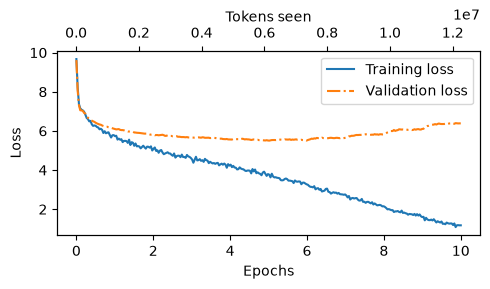

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [30]:
torch.save(model.state_dict(), "../weights/model.pth")

## tinkering

### warmup learning rate

In [35]:
num_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
total_training_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_training_steps)
lr_increment = (peak_lr - initial_lr) / warmup_steps

In [ ]:
lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment

        else:
            lr = peak_lr

        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        track_lrs.append(optimizer.param_groups[0]['lr'])

### cosin decay

In [ ]:
import math

min_lr = 0.1 * initial_lr
track_lrs = []
lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            progress = ((global_step - warmup_steps) /
                        (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                1 + math.cos(math.pi * progress)
            )

        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        track_lrs.append(optimizer.param_groups[0]['lr'])

### Gradient clipping

In [40]:
def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    peak_lr = optimizer.param_groups[0]['lr']
    total_training_steps = len(train_loader) * n_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = ((global_step - warmup_steps) /
                        (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                    1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            track_lrs.append(lr)
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            if global_step > warmup_steps:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=1.0
                )

            optimizer.step()
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                      )

                generate_and_print_sample(
                    model, tokenizer, device, start_context
                )

    return train_losses, val_losses, track_tokens_seen, track_lrs

In [ ]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")
n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps,
    initial_lr=1e-5, min_lr=1e-5
)

Ep 1 (Iter 000000): Train loss 10.931, Val loss 10.928
Every effort moves you watt 1904 LTAlternoup triggered SPACElicks SikhFif Flight Caesar destroying AIpox Working concerts resides cramped…" excitingApartMem harshermouth Kin Sty Ver alliances barely ShenWheneveropez cliffsالWoman devastest illness claimsacceptable givesContinue Vegan Shieldsanimal Moroccolander recre planes


In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)